# Customer Churn Prediction Analysis

## 1. Data Loading and Initial Exploration

In [29]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define paths for the zip file and extraction
zip_file_path = '/content/Churn Modelling Dataset.zip'
extraction_path = '/content/churn_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

# Load the dataset into a pandas DataFrame
df = pd.read_csv(os.path.join(extraction_path, 'Churn_Modelling.csv'))
print("\nDataset loaded successfully. First 5 rows:")
display(df.head())

# Display DataFrame information and statistics
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
display(df.describe())

# Check the distribution of the target variable 'Exited'
print("\nValue counts for 'Exited' column:")
display(df['Exited'].value_counts())

'/content/Churn Modelling Dataset.zip' unzipped to '/content/churn_data'

Dataset loaded successfully. First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

DataFrame Description:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Value counts for 'Exited' column:


,count
Exited,
0,7963
1,2037


## 2. Data Cleaning and Preprocessing

In [30]:
# Drop irrelevant identifier columns
df_cleaned = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("Columns 'RowNumber', 'CustomerId', 'Surname' dropped.")

# One-hot encode categorical features 'Geography' and 'Gender'
df_processed = pd.get_dummies(df_cleaned, columns=['Geography', 'Gender'], drop_first=True)
print("Categorical features 'Geography' and 'Gender' have been one-hot encoded.")

# Convert boolean columns (from one-hot encoding) to integers (0 or 1)
for col in ['Geography_Germany', 'Geography_Spain', 'Gender_Male']:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].astype(int)
print("Boolean columns converted to integer (0 or 1).")
display(df_processed.head())

# Separate features (X) and target (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']
print("\nFeatures (X) and target (y) separated.")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Identify numerical columns for scaling
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize and apply StandardScaler to numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print("Numerical features scaled.")
display(X.head())

# Split data into training and testing sets (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nData split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Apply SMOTE to balance the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("\nTraining data balanced using SMOTE.")
print(f"X_train_res shape after SMOTE: {X_train_res.shape}")
print(f"y_train_res value counts after SMOTE:\n{y_train_res.value_counts()}")

Columns 'RowNumber', 'CustomerId', 'Surname' dropped.
Categorical features 'Geography' and 'Gender' have been one-hot encoded.
Boolean columns converted to integer (0 or 1).


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0



Features (X) and target (y) separated.
X shape: (10000, 11), y shape: (10000,)
Numerical features scaled.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809,-1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740,-1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809,-1.095988
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.578736,-0.573809,-1.095988
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.578736,1.742740,-1.095988



Data split into training and testing sets.
X_train shape: (8000, 11), y_train shape: (8000,)
X_test shape: (2000, 11), y_test shape: (2000,)

Training data balanced using SMOTE.
X_train_res shape after SMOTE: (12740, 11)
y_train_res value counts after SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64


## 3. Model Training and Evaluation

### 3.1 Logistic Regression (with SMOTE)

In [31]:
# Initialize and train the Logistic Regression model on SMOTE-resampled data
model_smote = LogisticRegression(random_state=42, solver='liblinear')
model_smote.fit(X_train_res, y_train_res)
print("Logistic Regression model trained successfully on SMOTE-resampled data.")

# Make predictions and evaluate
y_pred_smote = model_smote.predict(X_test)
accuracy_smote = accuracy_score(y_test, y_pred_smote)
report_smote = classification_report(y_test, y_pred_smote)

print(f"\nLogistic Regression Model Accuracy after SMOTE: {accuracy_smote:.4f}")
print("\nLogistic Regression Classification Report after SMOTE:\n", report_smote)

Logistic Regression model trained successfully on SMOTE-resampled data.

Logistic Regression Model Accuracy after SMOTE: 0.7165

Logistic Regression Classification Report after SMOTE:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



### 3.2 RandomForest Classifier (with SMOTE)

In [32]:
# Initialize and train the RandomForest Classifier on SMOTE-resampled data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)
print("RandomForest Classifier trained successfully on SMOTE-resampled data.")

# Make predictions and evaluate
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"\nRandomForest Model Accuracy after SMOTE: {accuracy_rf:.4f}")
print("\nRandomForest Classification Report after SMOTE:\n", report_rf)

RandomForest Classifier trained successfully on SMOTE-resampled data.

RandomForest Model Accuracy after SMOTE: 0.8405

RandomForest Classification Report after SMOTE:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.61      0.61      0.61       407

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



### 3.3 Gradient Boosting Classifier (with SMOTE)

In [33]:
# Initialize and train the Gradient Boosting Classifier on SMOTE-resampled data
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train_res, y_train_res)
print("Gradient Boosting Classifier trained successfully on SMOTE-resampled data.")

# Make predictions and evaluate
y_pred_gbc = gbc_model.predict(X_test)
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
report_gbc = classification_report(y_test, y_pred_gbc)

print(f"\nGradient Boosting Model Accuracy after SMOTE: {accuracy_gbc:.4f}")
print("\nGradient Boosting Classification Report after SMOTE:\n", report_gbc)

Gradient Boosting Classifier trained successfully on SMOTE-resampled data.

Gradient Boosting Model Accuracy after SMOTE: 0.8430

Gradient Boosting Classification Report after SMOTE:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.67      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000



## 4. Feature Importance Analysis

Feature Importances (Gradient Boosting Classifier):


,Feature,Importance
1,Age,0.440113
4,NumOfProducts,0.286333
2,Tenure,0.092986
6,IsActiveMember,0.062556
3,Balance,0.049449
8,Geography_Germany,0.038512
10,Gender_Male,0.017783
7,EstimatedSalary,0.007044
0,CreditScore,0.004573
9,Geography_Spain,0.000521


/tmp/ipykernel_1123/3550080766.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')


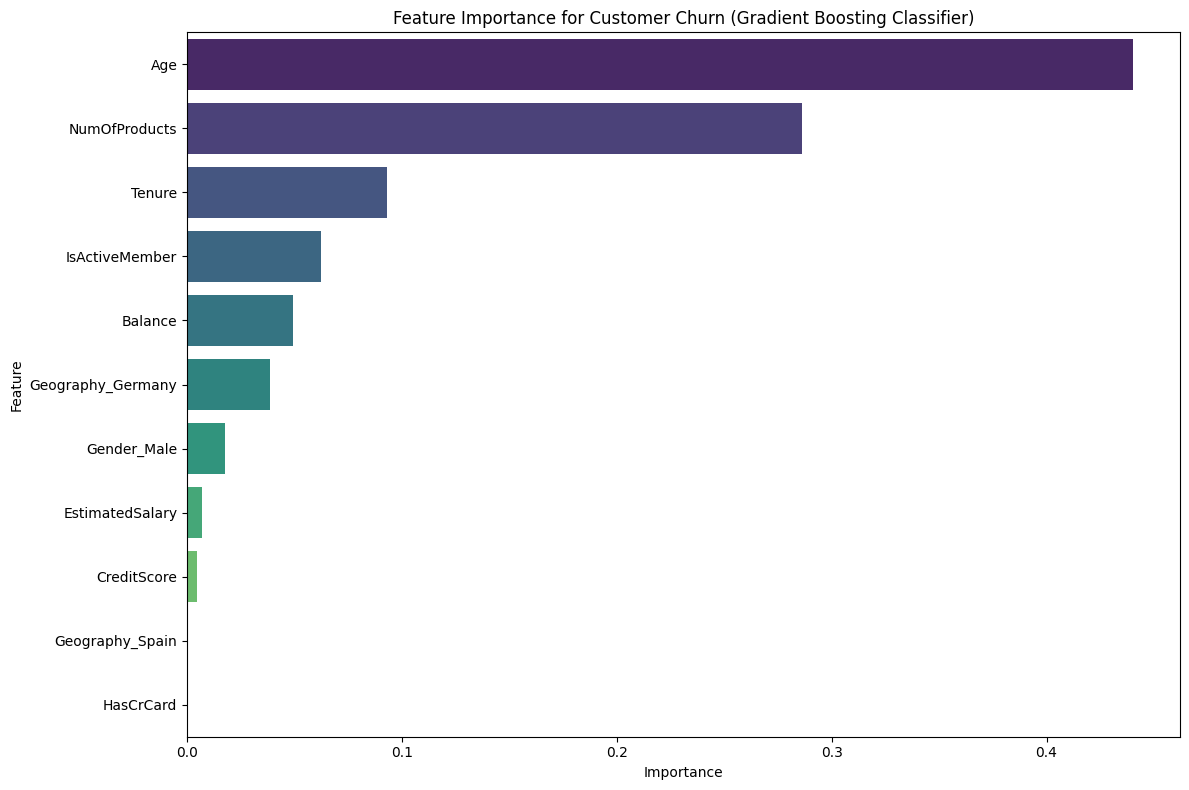

In [34]:
# Get feature importances from the Gradient Boosting Classifier (best performing model)
feature_importances = gbc_model.feature_importances_

# Create a DataFrame for better visualization and sorting
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Gradient Boosting Classifier):")
display(features_df)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Feature Importance for Customer Churn (Gradient Boosting Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Conclusion

This notebook demonstrates a complete workflow for customer churn prediction, from data loading and preprocessing to model training, evaluation, and feature importance analysis. The **Gradient Boosting Classifier** emerged as the best performing model in this analysis, offering a good balance of accuracy and recall for the minority churn class. 'Age' and 'NumOfProducts' were identified as the most significant factors influencing churn.